In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import seaborn as sns

In [3]:
data = load_breast_cancer()
description = data.DESCR.split('\n')
print("\n".join(description[11:31]))


:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - class:
            - WDBC-Malignant
            - WDBC-Benign


In [4]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.shape

(569, 31)

<function matplotlib.pyplot.show(close=None, block=None)>

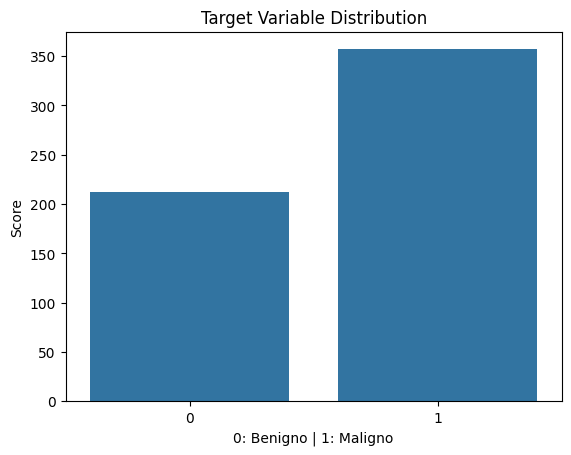

In [5]:
sns.countplot(x= 'target',data = df)
plt.title('Target Variable Distribution')
plt.xlabel('0: Benigno | 1: Maligno')
plt.ylabel('Score')
plt.show

### Decision Tree

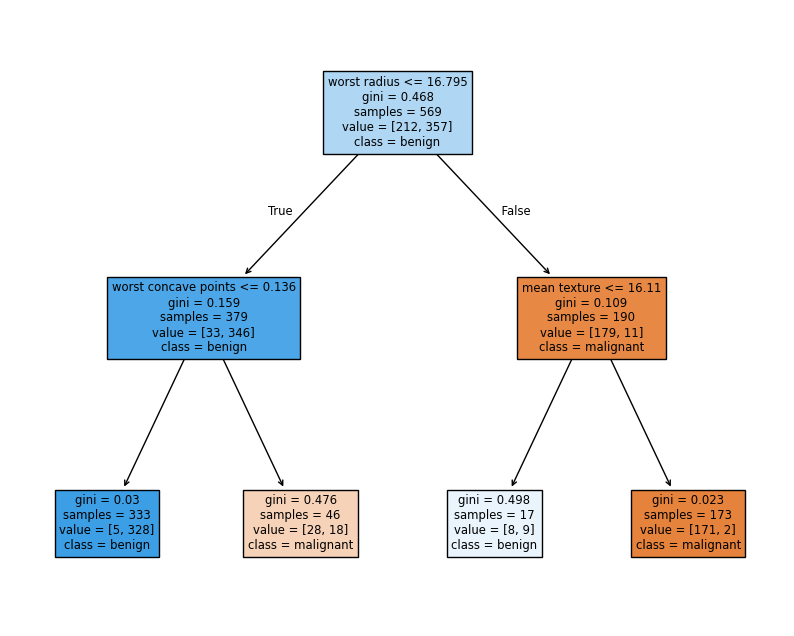

In [6]:
clf = DecisionTreeClassifier(max_depth=2)
x = data.data
y = data.target

clf.fit(x,y)
plt.figure(figsize=(10,8))
plot_tree(clf, filled=True, feature_names= data.feature_names, class_names= data.target_names)
plt.show()

Conseguir reconhecer as características que mais influenciam.

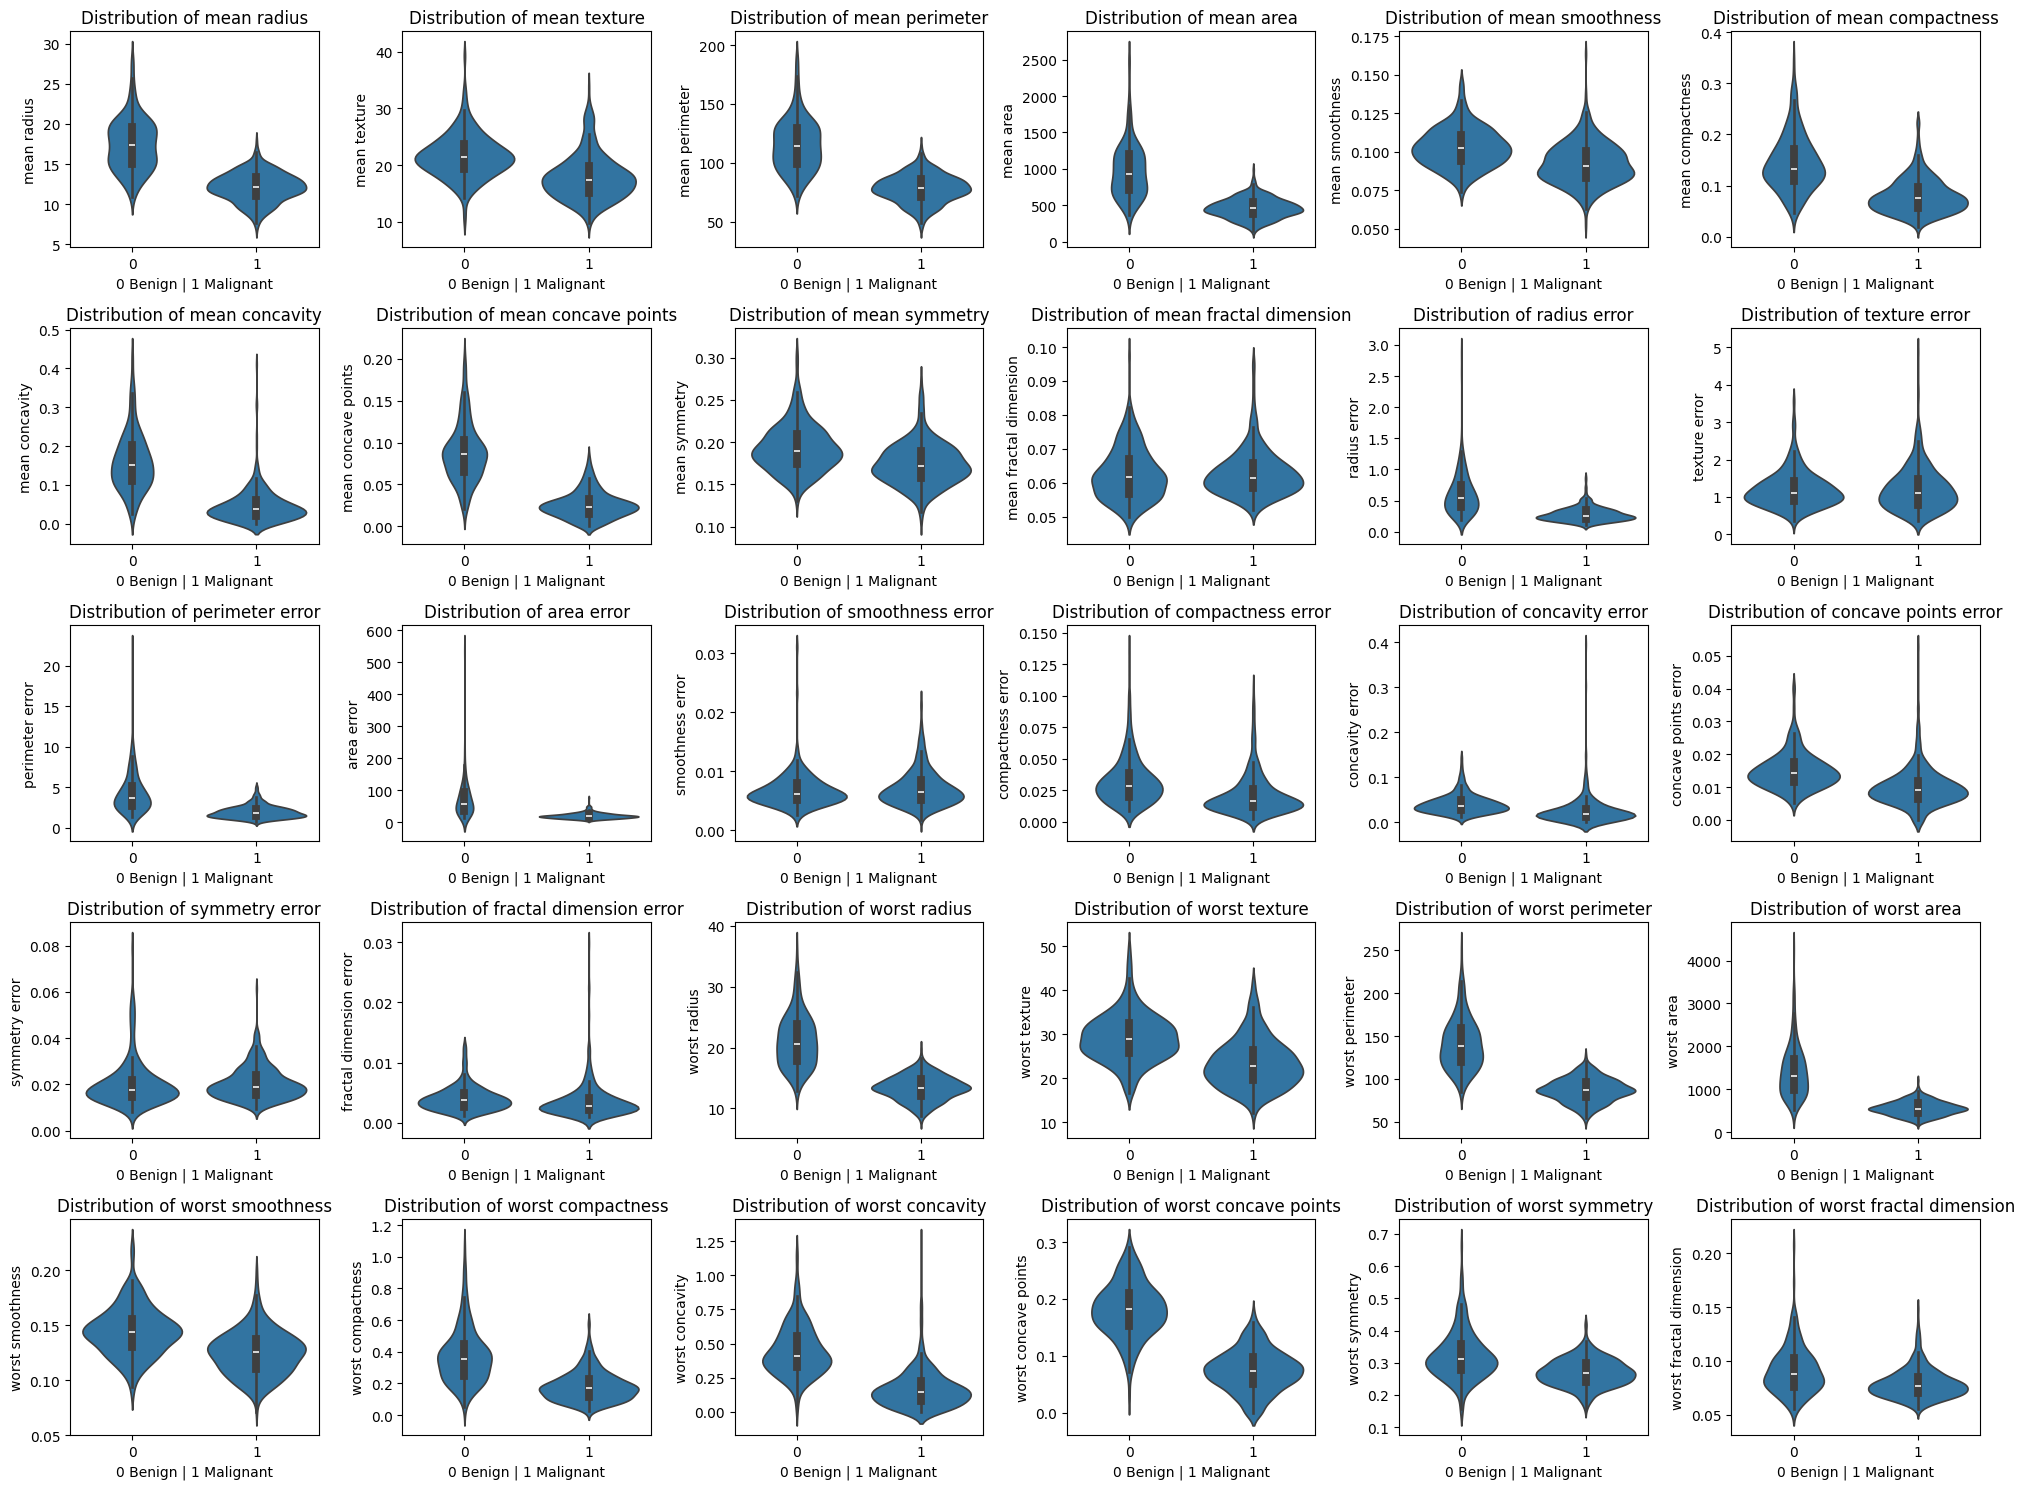

In [7]:
features = df.columns[:-1]
fig, axs = plt.subplots(nrows=5, ncols=6, figsize=(20,15))
axs = axs.flatten()
for i, feature in enumerate(features):
    sns.violinplot(x= 'target', y=feature, data=df, split=False, ax=axs[i])
    axs[i].set_title(f'Distribution of {feature}')
    axs[i].set_xlabel('0 Benign | 1 Malignant')
    axs[i].set_ylabel(feature)

for i in range(len(features), len(axs)):
    axs[i].remove()

plt.tight_layout()
plt.show()

In [8]:
scaler = StandardScaler()
x = scaler.fit_transform(x)
x

array([[ 1.09706398, -2.07333501,  1.26993369, ...,  2.29607613,
         2.75062224,  1.93701461],
       [ 1.82982061, -0.35363241,  1.68595471, ...,  1.0870843 ,
        -0.24388967,  0.28118999],
       [ 1.57988811,  0.45618695,  1.56650313, ...,  1.95500035,
         1.152255  ,  0.20139121],
       ...,
       [ 0.70228425,  2.0455738 ,  0.67267578, ...,  0.41406869,
        -1.10454895, -0.31840916],
       [ 1.83834103,  2.33645719,  1.98252415, ...,  2.28998549,
         1.91908301,  2.21963528],
       [-1.80840125,  1.22179204, -1.81438851, ..., -1.74506282,
        -0.04813821, -0.75120669]])

### Testes!

In [9]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.25, random_state=0)

In [10]:
from sklearn.svm import SVC
svm = SVC(kernel='linear', C=1)
svm.fit(x_train, y_train)

SVC(C=1, kernel='linear')

In [11]:
previsoes = svm.predict(x_test)
from sklearn.metrics import accuracy_score, classification_report
accuracy_score(y_test, previsoes)

0.972027972027972

## PCA - Principal Components Analysis

Pega todas as features originais e transforma em atributos cientéficos. É possível reduzir pra quantos componentes você quiser.

In [12]:
from sklearn.decomposition import PCA
pca = PCA(n_components=5)

x_train_pca = pca.fit_transform(x_train)
x_test_pdca = pca.fit_transform(x_test)
x_train_pca

array([[-2.8380771 , -0.3193802 , -0.50978696,  0.22007787, -0.52742285],
       [-3.23881077,  0.94669515,  1.4630147 ,  0.84543648, -3.50859759],
       [ 3.92831902, -3.3009157 ,  1.84183164,  2.83333596, -0.09483364],
       ...,
       [-3.17962251,  0.43326773,  0.57700503,  0.11186201, -0.75630282],
       [-5.59141525, -0.75288918,  4.06478207,  2.61732114, -0.95172627],
       [-1.20802261,  1.32965049,  1.26115052,  3.49517444,  1.34529382]])

In [13]:
svm_pca = SVC(kernel='linear', C=2)
svm_pca.fit(x_train, y_train)

SVC(C=2, kernel='linear')

## Outros - Quando Dimensão Prejudica o Algoritmo

1. Teste Qui-Quadrado (Chi²) -
Mede grau de dependência entre duas variáveis categóricas.

2. ANOVA (Analysis of Variance) - 
Usado para verificar se há diferença significativa entre médias de um ou mais grupos.

In [14]:
from sklearn.feature_selection import f_classif, SelectKBest

selecao = SelectKBest(f_classif, k=7)
x_anova = selecao.fit_transform(x,y)

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x_anova,y , test_size=0.3, random_state=42)

In [16]:
svm_anova = SVC(kernel = 'linear', C= 2)
svm_anova.fit(x_train, y_train)

SVC(C=2, kernel='linear')

In [17]:
previsoes = svm_anova.predict(x_test)
accuracy_score(y_test, previsoes)

0.9766081871345029

## Grid Search

In [19]:
from sklearn.model_selection import GridSearchCV
parametros = {'C': [1.0,1.5,2.0],
              'kernel': ['rbf', 'linear','poly', 'sigmoid']}

In [21]:
grid_search = GridSearchCV(estimator=SVC(), param_grid=parametros)
grid_search.fit(x,y)
melhores_parametros = grid_search.best_params_
melhor_resultado = grid_search.best_score_
print(melhores_parametros)
print(melhor_resultado)

{'C': 1.5, 'kernel': 'rbf'}
0.9771619313771154
